In [259]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os
import cartopy.crs as ccrs;import cartopy.feature as cfeature
from matplotlib.gridspec import GridSpec

In [260]:
# gndirt
# Description: Infrared Thermometer: Ground surface temperature
# Site: Houston, TX; Tracking Aerosol Convection interactions ExpeRiment (HOU)
# Location: Houston, TX; AMF1 (main site for TRACER) 
# Facility Code: M1
# Category: Radiometric
# Data Type: Routine Data 
# Source Instrument/Data: Infrared Thermometer 
# Start Date: 2021-08-04 
# End Date: 2022-10-01 

In [261]:
import glob
import xarray as xr

data_location = '/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/Figures/campaign_data/surface_data/'

# Search for files containing "20220622"
search_date = "20220622"
matching_files = glob.glob(f"{data_location}*{search_date}*.nc")

# Open the first matching file if it exists
if matching_files:
    file_to_open = matching_files[0]  # Take the first match
    print(f"Opening file: {file_to_open}")
    ds = xr.open_dataset(file_to_open)
else:
    print("No file found for the given date.")


Opening file: /mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/Figures/campaign_data/surface_data/hougndirtM1.b1.20220622.000000.nc


Text(0.5, 1.0, 'Diurnal Cycle of Infrared Thermometer: Ground Surface Temp at ARM M1 Facility on 06/22/22')

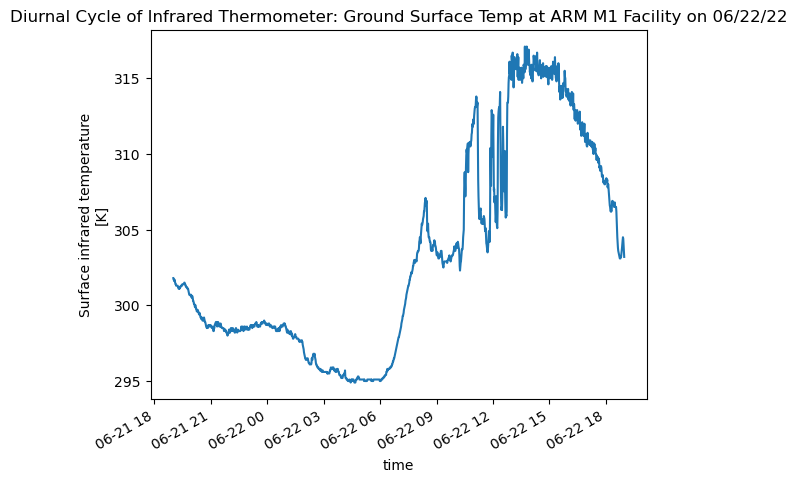

In [262]:
timestamps=ds['time']
ds['time'] = ds['time'] - np.timedelta64(5, 'h')

search_date = "2022-06-22"

# Find matching timestamps
matches = np.char.startswith(timestamps.astype(str), search_date)
where=np.where(matches==True)

ds['sfc_ir_temp'][where].plot()
plt.title('Diurnal Cycle of Infrared Thermometer: Ground Surface Temp at ARM M1 Facility on 06/22/22')

In [265]:
#Description: ERA5 hourly data on single levels from 1940 to present

In [278]:
data_location='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/Figures/campaign_data'
data=xr.open_dataset(data_location+'/era5.nc') 

<xarray.Dataset>
Dimensions:     (valid_time: 24, latitude: 721, longitude: 1440)
Coordinates:
    number      int64 ...
  * valid_time  (valid_time) datetime64[ns] 2022-06-22 ... 2022-06-22T23:00:00
  * latitude    (latitude) float64 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    expver      (valid_time) object ...
Data variables:
    sst         (valid_time, latitude, longitude) float32 ...
    skt         (valid_time, latitude, longitude) float32 ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-02-07T01:37 GRIB to CDM+CF via cfgrib-0.9.1...

In [295]:
#GET DATA
bot_lat_ind,top_lat_ind=25,38
left_lon_ind,right_lon_ind=255,270
bot_lat=data['latitude'][bot_lat_ind].item()
top_lat=data['latitude'][top_lat_ind].item()
left_lon=data['longitude'][left_lon_ind].item()
right_lon=data['longitude'][right_lon_ind].item()
sst_og = data['sst'].sel(latitude=slice(top_lat_ind,bot_lat_ind),longitude=slice(left_lon_ind,right_lon_ind))
# sst_og = sst.isel(latitude=slice(None, None, -1))  # Flip latitude
skt_og = data['skt'].sel(latitude=slice(top_lat_ind,bot_lat_ind),longitude=slice(left_lon_ind,right_lon_ind))
# skt_og = skt.isel(latitude=slice(None, None, -1))  # Flip latitude

sst=sst_og.isel(valid_time=t_where)[0]
skt=skt_og.isel(valid_time=t_where)[0]


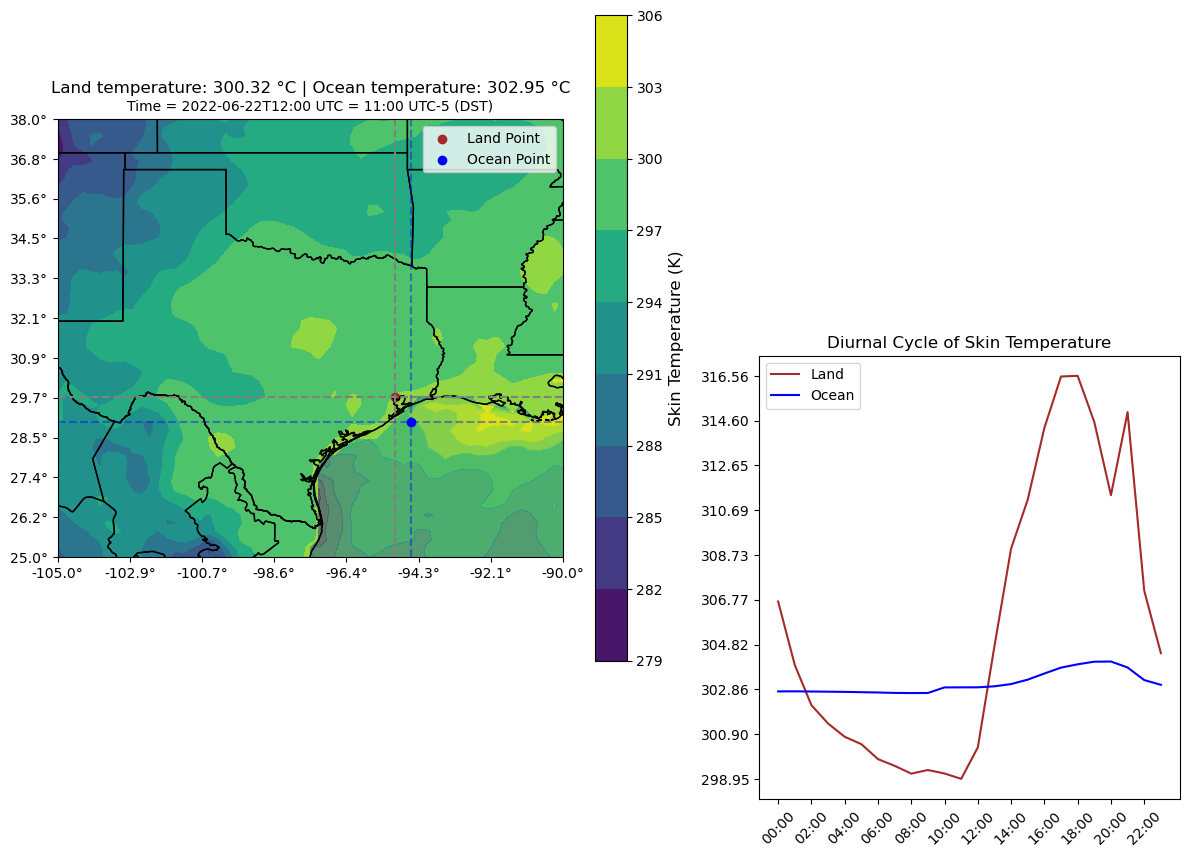

In [393]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Assuming `data` is a dataset and already loaded
# Replace with your actual data loading process


# Extract time values
timestamps = data['valid_time'].values.astype(str)
t_where = np.where(np.char.startswith(timestamps, '2022-06-22T12'))[0]

#GET DATA
bot_lat_ind,top_lat_ind=25,38
left_lon_ind,right_lon_ind=255,270
bot_lat=data['latitude'][bot_lat_ind].item()
top_lat=data['latitude'][top_lat_ind].item()
left_lon=data['longitude'][left_lon_ind].item()
right_lon=data['longitude'][right_lon_ind].item()
sst_og = data['sst'].sel(latitude=slice(top_lat_ind,bot_lat_ind),longitude=slice(left_lon_ind,right_lon_ind))
skt_og = data['skt'].sel(latitude=slice(top_lat_ind,bot_lat_ind),longitude=slice(left_lon_ind,right_lon_ind))

sst=sst_og.isel(valid_time=t_where)[0]
skt=skt_og.isel(valid_time=t_where)[0]
sst = sst.isel(latitude=slice(None, None, -1))  # Flip latitude
skt = skt.isel(latitude=slice(None, None, -1))  # Flip latitude
sst_og = sst_og.isel(latitude=slice(None, None, -1))  # Flip latitude
skt_og = skt_og.isel(latitude=slice(None, None, -1))  # Flip latitude

# Create figure and GridSpec layout
fig = plt.figure(figsize=(12, 10), dpi=100)
gs = GridSpec(nrows=2, ncols=2, figure=fig, height_ratios=[1, 1], width_ratios=[3, 2])

# Main map plot
ax1 = fig.add_subplot(gs[:, 0], projection=ccrs.PlateCarree())
contour = ax1.contourf(skt['longitude'], skt['latitude'],skt, transform=ccrs.PlateCarree(), cmap='viridis')
cbar = plt.colorbar(contour, ax=ax1, shrink=0.7)
cbar.set_label("Skin Temperature (K)", fontsize=12)
# contour = ax1.contourf(sst['longitude'], sst['latitude'],sst, transform=ccrs.PlateCarree(), cmap='viridis')
# cbar = plt.colorbar(contour, ax=ax1, shrink=0.7)
# cbar.set_label("Sea Surface Temperature (K)", fontsize=12)

# skt_land_only = skt.where(~np.isnan(sst))  # Mask SKT where SST is NaN
# contour_skt = ax1.contourf(skt_land_only['longitude'], skt_land_only['latitude'], skt_land_only, 
#                              transform=ccrs.PlateCarree(), cmap='viridis', alpha=0.6)


# Add geographical features
ax1.add_feature(cfeature.BORDERS, linestyle='-', edgecolor='black')
ax1.add_feature(cfeature.STATES, linestyle='-', edgecolor='black')
ax1.coastlines()


###############################################################################################################
#Adding Line Markers
ax1.axvline(land_lon,linestyle='dashed',color='grey')
ax1.axhline(land_lat,linestyle='dashed',color='grey')
ax1.axvline(ocean_lon,linestyle='dashed',color='blue',alpha=0.4)
ax1.axhline(ocean_lat,linestyle='dashed',color='blue',alpha=0.4)

# import matplotlib.ticker as ticker
# ax2.yaxis.set_major_locator(ticker.MaxNLocator(nbins=12))

###############################################################################################################

# Convert longitudes from 0-360 to -180 to 180
sst_og = sst_og.assign_coords(longitude=((sst_og.longitude + 180) % 360 - 180))
skt_og = skt_og.assign_coords(longitude=((skt_og.longitude + 180) % 360 - 180))
sst = sst.assign_coords(longitude=((sst.longitude + 180) % 360 - 180))
skt = skt.assign_coords(longitude=((skt.longitude + 180) % 360 - 180))

# Get data limits
lon_min, lon_max = skt.longitude.min().item(), skt.longitude.max().item()
lat_min, lat_max = skt.latitude.min().item(), skt.latitude.max().item()

# Define tick positions
lon_ticks = np.linspace(lon_min, lon_max, num=8)
lat_ticks = np.linspace(lat_min, lat_max, num=12)

# Set extent
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Set ticks
ax1.set_xticks(lon_ticks, crs=ccrs.PlateCarree())
ax1.set_yticks(lat_ticks, crs=ccrs.PlateCarree())

# Format tick labels
ax1.set_xticklabels([f"{lon:.1f}°" for lon in lon_ticks], fontsize=10)
ax1.set_yticklabels([f"{lat:.1f}°" for lat in lat_ticks], fontsize=10)

###########################################################################################

# Select land and ocean locations
# lon = -95.059
# lat = 29.67
land_lat = 29.75
ocean_lat = 29
land_lon = -95  
ocean_lon = -94.5
# Scatter points for land and ocean
ax1.scatter(land_lon, land_lat, color='brown', label="Land Point")  # Land point
ax1.scatter(ocean_lon, ocean_lat, color='blue', label="Ocean Point")  # Ocean point

landtemp_val=skt.sel(latitude=land_lat,longitude=land_lon,method='nearest').item()
oceantemp_val=skt.sel(latitude=ocean_lat,longitude=ocean_lon,method='nearest').item()
ax1.text(0.5, 1.05, f'Land temperature: {landtemp_val:.2f} °C | Ocean temperature: {oceantemp_val:.2f} °C',  
         ha='center', va='bottom', fontsize=12, transform=ax1.transAxes)

###########################################################################################
ax1.set_title(f'Time = {timestamps[t_where[0]][:13]}:00 UTC = 11:00 UTC-5 (DST)', fontsize=10)
ax1.legend(loc="upper right", fontsize=10)
###########################################################################################

skt_diurnal_land=skt_og.sel(latitude=land_lat,longitude=land_lon,method='nearest').values
skt_diurnal_ocean=skt_og.sel(latitude=ocean_lat,longitude=ocean_lon,method='nearest').values

#TIME TICKS
import pandas as pd; time_values = pd.to_datetime(skt_og['valid_time'].values)

# Land temperature time series plot
ax2 = fig.add_subplot(gs[1, 1])
ax2.plot(time_values,skt_diurnal_land, color='brown',label='Land')

# Ocean temperature time series plot
ax2.plot(time_values,skt_diurnal_ocean, color='blue',label='Ocean')

#TIME TICKS
ax2.set_xticks(time_values[::2])  # Show every 3rd tick to avoid clutter
ax2.set_xticklabels(time_values[::2].strftime('%H:%M'), rotation=45, fontsize=10)  # Format as HH:MM


###########################################################################################
y_min = min(skt_diurnal_land.min(), skt_diurnal_ocean.min())  
y_max = max(skt_diurnal_land.max(), skt_diurnal_ocean.max())  

# Define y-ticks including min and max values
num_ticks = 10  # Adjust number of ticks as needed
y_ticks = np.linspace(y_min, y_max, num=num_ticks)
ax2.set_yticks(y_ticks);

###########################################################################################
ax2.set_title('Diurnal Cycle of Skin Temperature')            
ax2.legend(loc="upper left", fontsize=10)
plt.tight_layout()
plt.tight_layout()


In [ ]:
# ECMWFSFCE
# ECMWF: near-surface and surface variables (extra), entire coverage, 1-hr avg
# Data Level:
# c1
# Site: Houston, TX, USA; Mobile Facility (TRACER) (HOU)
# Facility: External Data (satellites and others) (X1)
# Category: Derived Quantities and Models
# Source Instrument/Data: European Centre for Medium Range Weather Forecasts Diagnostic Analyses (ecmwfdiag)
# Datetime Range:  2022-03-20 00:00:00 to 2022-09-01 00:00:00

Text(0.5, 1.0, 'ECMWFSFCE Diurnal Cycle on 06/22/22')

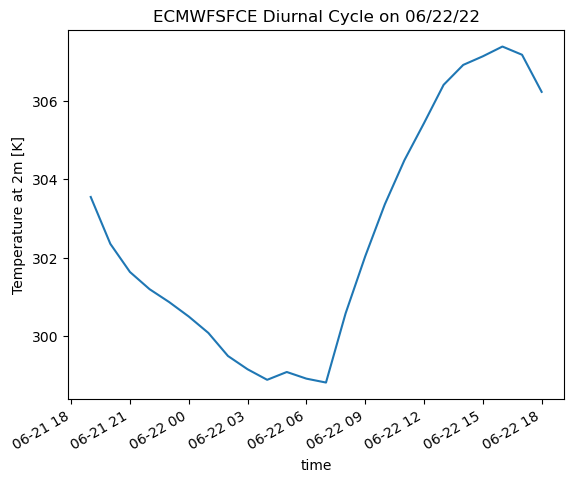

In [394]:
data_location='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/Figures/campaign_data/surface_data/'
data2=xr.open_dataset(data_location+'houecmwfsfceX1.c1.20220601.000000.nc')

timestamps=data2['time']
data2['time'] = data2['time'] - np.timedelta64(5, 'h')

search_date = "2022-06-22"

# Find matching timestamps
matches = np.char.startswith(timestamps.astype(str), search_date)
where=np.where(matches==True)

data2['temperature_2m'][where].plot()#.isel(time=slice(500,550)).plot()
plt.title('ECMWFSFCE Diurnal Cycle on 06/22/22')